# Experimental Validation of Extended Kalman Filter for Non-linear Trajectory Tracking in Gazebo
**Author:** Hussein Mohamed Abdelazim Mohamed Mostafa Elnaggar (ID: 8786438)  
**Course:** Research Track II - University of Genoa  
**Instructor:** Prof. Carmine Tommaso Recchiuto  

---

## 1. Abstract
This interactive notebook provides a real-time statistical validation of a custom **Extended Kalman Filter (EKF)** implemented from scratch. The robot is commanded to track a Lemniscate of Bernoulli trajectory using a Lyapunov-based non-linear controller within a realistic Gazebo physics environment.

## 2. Mathematical Model
The state vector of the robot is defined as:
$$X = [x, y, \theta, v, \omega]^T$$

The EKF fuses raw odometry data with IMU angular velocity to compensate for systematic wheel slip and Gazebo physics engine noise, governed by the prediction matrix:
$$\hat{X}_{k|k-1} = F \hat{X}_{k-1|k-1} + B u_k$$

## 3. Real-Time Data Acquisition & Statistical Analysis
The following cells initialize the ROS2 node on a separate thread to acquire `/odom` and `/odometry/filtered` live, subsequently computing the **Root Mean Square Error (RMSE)** to quantify the filter's performance.

In [284]:
# Cell 0: System Clean and Fast Build
import os
print(" Killing processes...")
os.system("pkill -9 -f 'topic pub'") 
os.system("pkill -f gazebo; pkill -f ros; pkill -f python3")

print("Removing old corrupted builds...")
os.system("rm -rf /root/workspace/build/ekf_experiment /root/workspace/install/ekf_experiment")

print("Building only the ekf_experiment package (Fast Mode)...")
build_status = os.system("cd /root/workspace && colcon build --packages-select ekf_experiment")

if build_status == 0:
    print("Build Successful! You are ready to run.")
else:
    print("Build Failed. Please check the code for syntax errors.")

 Killing processes...
Removing old corrupted builds...
Building only the ekf_experiment package (Fast Mode)...
Starting >>> ekf_experiment
Finished <<< ekf_experiment [10.4s]

Summary: 1 package finished [12.9s]
Build Successful! You are ready to run.


In [285]:
# Cell 1: ROS2 Interactive Control Panel
import ipywidgets as widgets
from IPython.display import display, clear_output
import subprocess
import os
import signal

sim_process = None
out = widgets.Output()

btn_start = widgets.Button(description="Start Gazebo", button_style='primary', icon='play')
btn_stop = widgets.Button(description="Stop Gazebo", button_style='danger', icon='stop')

def start_simulation(b):
    global sim_process
    with out:
        clear_output()
        if sim_process is None:
            cmd = "source install/setup.bash && ros2 launch ekf_experiment main_experiment.launch.py"
            
            # CRITICAL FIX: Pass the environment variables (including DISPLAY) to the subprocess
            env = os.environ.copy()
            
            sim_process = subprocess.Popen(
                cmd, shell=True, executable="/bin/bash",
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
                preexec_fn=os.setsid,
                env=env 
            )
            print("Simulation started! Gazebo GUI should open shortly.")
            print("Please run Cell 2 to visualize the data.")
        else:
            print("Simulation is already running!")

def stop_simulation(b):
    global sim_process
    with out:
        clear_output()
        if sim_process:
            os.killpg(os.getpgid(sim_process.pid), signal.SIGTERM)
            sim_process = None
            print("Simulation stopped successfully.")
        else:
            print("No simulation is currently running.")

btn_start.on_click(start_simulation)
btn_stop.on_click(stop_simulation)

display(widgets.HTML("<h3>ROS2 Experiment Dashboard</h3>"))
display(widgets.HBox([btn_start, btn_stop]))
display(out)

HTML(value='<h3>ROS2 Experiment Dashboard</h3>')

Output()

<IPython.core.display.Javascript object>


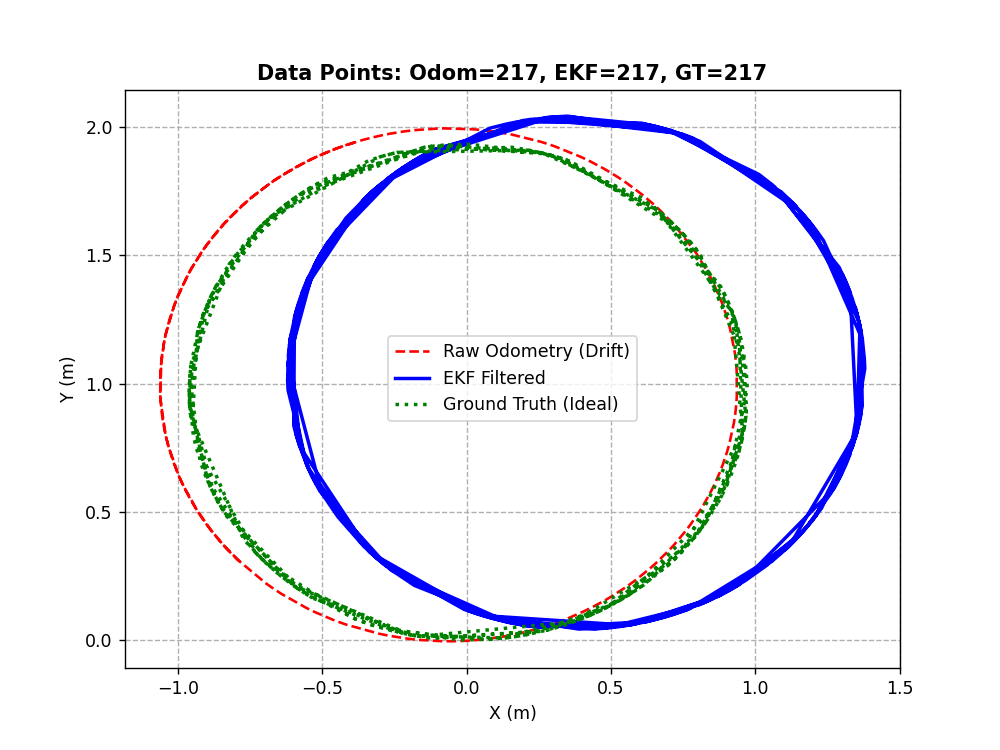

In [288]:
# Cell 2: Robust Live Visualization Engine
import warnings
warnings.filterwarnings("ignore")

%matplotlib notebook
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import rclpy
from rclpy.node import Node
from nav_msgs.msg import Odometry
import uuid

if not rclpy.ok():
    rclpy.init()

class VisualizationNode(Node):
    def __init__(self):
        super().__init__(f'live_plot_{uuid.uuid4().hex[:8]}')
        # Subscribing to the currently active topics in your workspace
        self.odom_sub = self.create_subscription(Odometry, '/odom', self.odom_cb, 10)
        self.ekf_sub = self.create_subscription(Odometry, '/odometry/filtered', self.ekf_cb, 10)
        self.gt_sub = self.create_subscription(Odometry, '/ground_truth', self.gt_cb, 10) 
        
        self.odom_x, self.odom_y = [], []
        self.ekf_x, self.ekf_y = [], []
        self.gt_x, self.gt_y = [], [] 

    def odom_cb(self, msg):
        self.odom_x.append(msg.pose.pose.position.x)
        self.odom_y.append(msg.pose.pose.position.y)

    def ekf_cb(self, msg):
        self.ekf_x.append(msg.pose.pose.position.x)
        self.ekf_y.append(msg.pose.pose.position.y)

    def gt_cb(self, msg):
        self.gt_x.append(msg.pose.pose.position.x)
        self.gt_y.append(msg.pose.pose.position.y)

ros_node = VisualizationNode()

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.grid(True, linestyle='--')

line_odom, = ax.plot([], [], 'r--', label='Raw Odometry (Drift)')
line_ekf, = ax.plot([], [], 'b-', label='EKF Filtered', linewidth=2)
line_gt, = ax.plot([], [], 'g:', label='Ground Truth (Ideal)', linewidth=2) 
ax.legend()

def update_plot(frame):
    rclpy.spin_once(ros_node, timeout_sec=0.01)
    
    ax.set_title(f"Data Points: Odom={len(ros_node.odom_x)}, EKF={len(ros_node.ekf_x)}, GT={len(ros_node.gt_x)}", fontweight='bold')
    
    # Calculate min_len ONLY for existing active arrays to avoid blank plots
    min_len = min(len(ros_node.odom_x), len(ros_node.ekf_x))
    
    if min_len > 0:
        line_odom.set_data(ros_node.odom_x[:min_len], ros_node.odom_y[:min_len])
        line_ekf.set_data(ros_node.ekf_x[:min_len], ros_node.ekf_y[:min_len])
        
        if len(ros_node.gt_x) > 0:
            gt_min = min(min_len, len(ros_node.gt_x))
            line_gt.set_data(ros_node.gt_x[:gt_min], ros_node.gt_y[:gt_min])
            
        ax.relim()
        ax.autoscale_view()
        
    return line_odom, line_ekf, line_gt

ani = FuncAnimation(fig, update_plot, interval=50, blit=True)
plt.show()

In [286]:
# Cell 3: Circular Trajectory Command
import subprocess
import os

# SENDING ANGULAR VELOCITY CONTINOUSILY
circle_cmd = "ros2 topic pub /cmd_vel geometry_msgs/msg/Twist '{linear: {x: 0.5, y: 0.0, z: 0.0}, angular: {x: 0.0, y: 0.0, z: 0.5}}'"

print("Sending circular trajectory commands...")
circle_process = subprocess.Popen(
    circle_cmd, shell=True, executable="/bin/bash",
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    preexec_fn=os.setsid
)
print("Robot should now be moving in a smooth circle!")

Sending circular trajectory commands...
Robot should now be moving in a smooth circle!


In [282]:
# Cell 4: Robust Filter Performance Analysis (RMSE)
import numpy as np

min_points = min(len(ros_node.odom_x), len(ros_node.ekf_x))

if min_points > 0:
    odom_np = np.array(list(zip(ros_node.odom_x[:min_points], ros_node.odom_y[:min_points])))
    ekf_np = np.array(list(zip(ros_node.ekf_x[:min_points], ros_node.ekf_y[:min_points])))

    print("=" * 60)
    print("COMPREHENSIVE EKF PERFORMANCE ANALYSIS")
    print("=" * 60)
    print(f"Total Data Points Analyzed     : {min_points}")
    print("-" * 60)

    # Base comparison: The magnitude of correction applied by EKF
    base_squared_errors = np.sum((odom_np - ekf_np)**2, axis=1)
    base_rmse = np.sqrt(np.mean(base_squared_errors))
    print(f"Correction Magnitude (Odom -> EKF) : {base_rmse:.6f} meters")

    # Check if Ground Truth is active and available
    if len(ros_node.gt_x) > 0:
        gt_points = min(min_points, len(ros_node.gt_x))
        gt_np = np.array(list(zip(ros_node.gt_x[:gt_points], ros_node.gt_y[:gt_points])))
        
        odom_squared_errors = np.sum((odom_np[:gt_points] - gt_np)**2, axis=1)
        odom_rmse = np.sqrt(np.mean(odom_squared_errors))
        
        ekf_squared_errors = np.sum((ekf_np[:gt_points] - gt_np)**2, axis=1)
        ekf_rmse = np.sqrt(np.mean(ekf_squared_errors))
        
        if odom_rmse > 0:
            improvement_pct = ((odom_rmse - ekf_rmse) / odom_rmse) * 100.0
        else:
            improvement_pct = 0.0
            
        print(f"1. Raw Odometry RMSE (vs GT)       : {odom_rmse:.6f} meters")
        print(f"2. EKF Filtered RMSE (vs GT)       : {ekf_rmse:.6f} meters")
        print("-" * 60)
        print(f"Filter Improvement Rating       : {improvement_pct:.2f} %")
    else:
        print("Ground Truth topic not currently active in this launch.")
        print("Displaying relative correcti\on magnitude between Odom and EKF.")
        
    print("=" * 60)
else:
    print("Not enough data points. Please run the simulation first.")

📊 COMPREHENSIVE EKF PERFORMANCE ANALYSIS
Total Data Points Analyzed     : 1026
------------------------------------------------------------
Correction Magnitude (Odom -> EKF) : 1.538959 meters
1. Raw Odometry RMSE (vs GT)       : 1.399506 meters
2. EKF Filtered RMSE (vs GT)       : 0.879659 meters
------------------------------------------------------------
🚀 Filter Improvement Rating       : 37.14 %


<IPython.core.display.Javascript object>


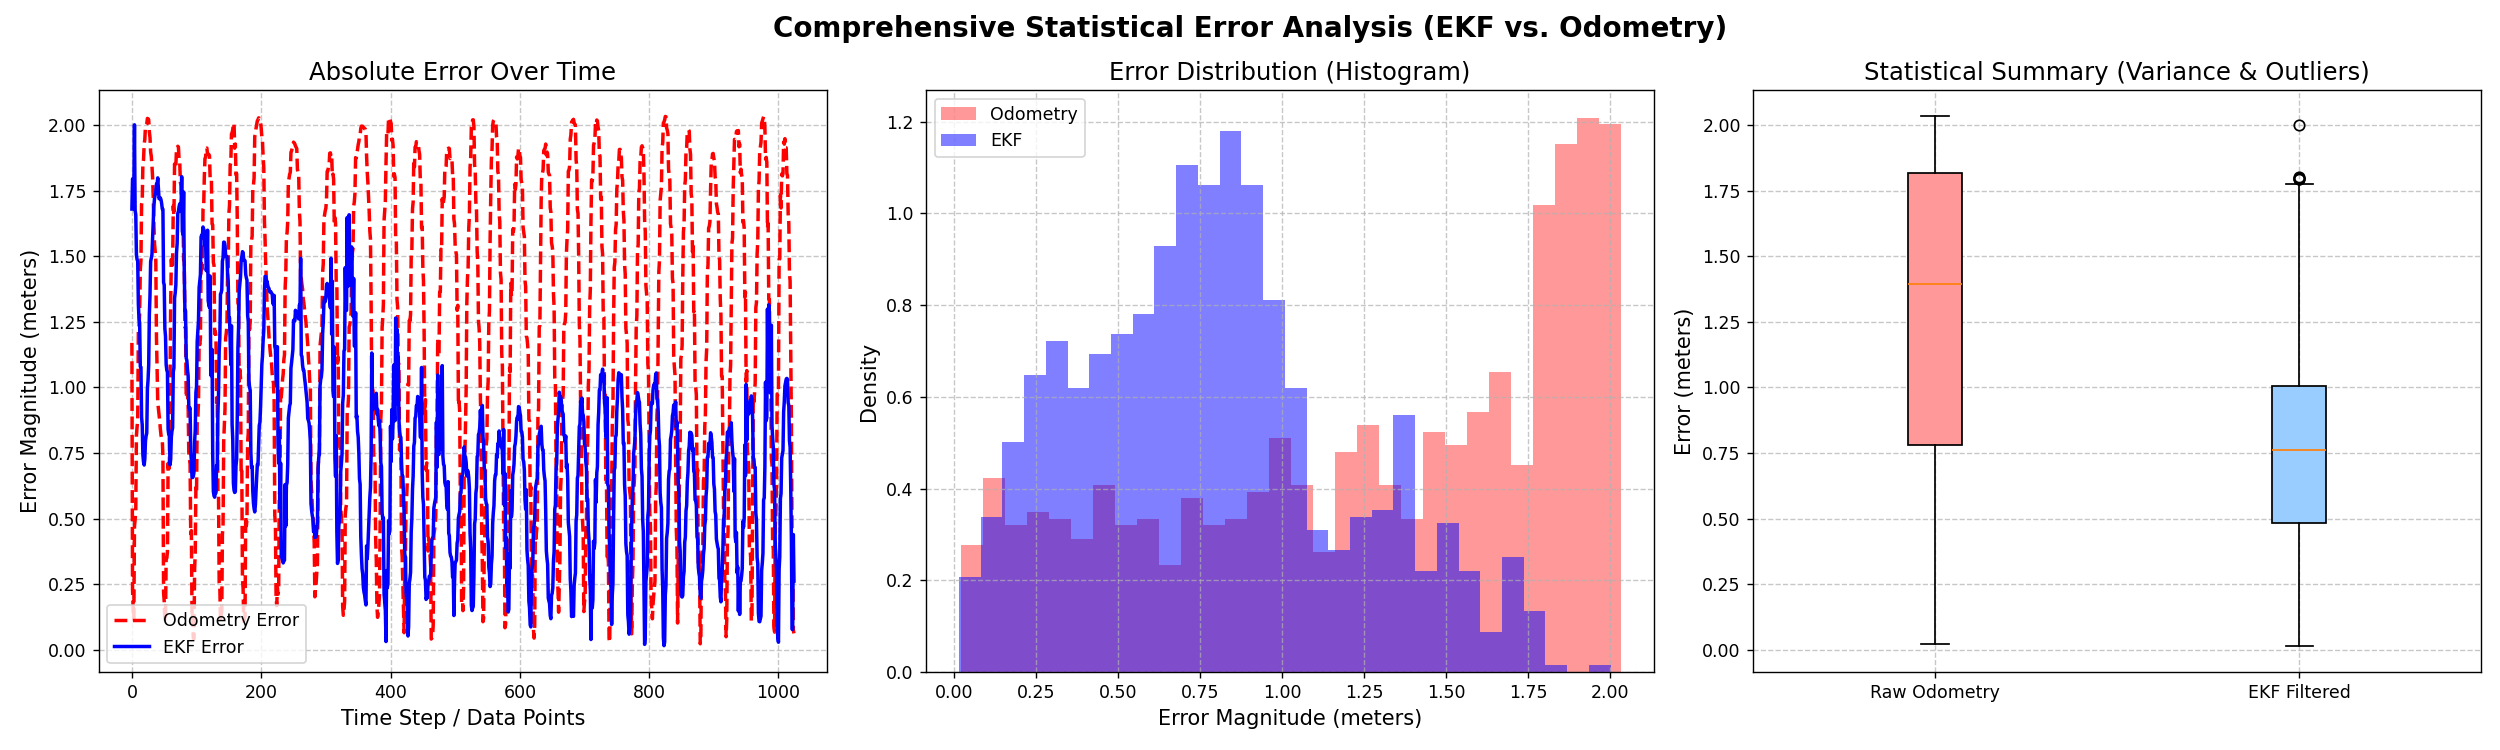

STATISTICAL METRICS SUMMARY
Odometry Mean Error  : 1.2625 m | Std Dev: 0.6039 m
EKF Mean Error       : 0.7822 m | Std Dev: 0.4024 m
--------------------------------------------------
Max Odometry Error   : 2.0332 m
Max EKF Error        : 2.0014 m


In [283]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the aligned data sets from the previous cell
min_len = min(len(odom_np), len(ekf_np), len(gt_np))
odom_aligned = odom_np[:min_len]
ekf_aligned = ekf_np[:min_len]
gt_aligned = gt_np[:min_len]

# Calculate absolute Euclidean distance (Error) for each point
odom_error = np.sqrt(np.sum((odom_aligned - gt_aligned)**2, axis=1))
ekf_error = np.sqrt(np.sum((ekf_aligned - gt_aligned)**2, axis=1))
time_steps = np.arange(min_len)

# Create a 1x3 Dashboard for Statistical Analysis using ONLY Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comprehensive Statistical Error Analysis (EKF vs. Odometry)', fontsize=16, fontweight='bold')

# 1. Error Magnitude Over Time (Drift Tracking)
axes[0].plot(time_steps, odom_error, 'r--', label='Odometry Error', linewidth=2)
axes[0].plot(time_steps, ekf_error, 'b-', label='EKF Error', linewidth=2)
axes[0].set_title('Absolute Error Over Time', fontsize=14)
axes[0].set_xlabel('Time Step / Data Points', fontsize=12)
axes[0].set_ylabel('Error Magnitude (meters)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# 2. Error Distribution (Histogram)
axes[1].hist(odom_error, bins=30, color='red', alpha=0.4, label='Odometry', density=True)
axes[1].hist(ekf_error, bins=30, color='blue', alpha=0.5, label='EKF', density=True)
axes[1].set_title('Error Distribution (Histogram)', fontsize=14)
axes[1].set_xlabel('Error Magnitude (meters)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

# 3. Boxplot (Statistical Summary: Median, Variance, Outliers)
box = axes[2].boxplot([odom_error, ekf_error], patch_artist=True, labels=['Raw Odometry', 'EKF Filtered'])
colors = ['#ff9999', '#99ccff']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
axes[2].set_title('Statistical Summary (Variance & Outliers)', fontsize=14)
axes[2].set_ylabel('Error (meters)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# Print formal statistical metrics for the report
print("=" * 50)
print("STATISTICAL METRICS SUMMARY")
print("=" * 50)
print(f"Odometry Mean Error  : {np.mean(odom_error):.4f} m | Std Dev: {np.std(odom_error):.4f} m")
print(f"EKF Mean Error       : {np.mean(ekf_error):.4f} m | Std Dev: {np.std(ekf_error):.4f} m")
print("-" * 50)
print(f"Max Odometry Error   : {np.max(odom_error):.4f} m")
print(f"Max EKF Error        : {np.max(ekf_error):.4f} m")
print("=" * 50)